# Superposition Hypothesis

**Companion to** [research/06-superposition-hypothesis.md](../research/06-superposition-hypothesis.md)

A model can encode **more features than it has dimensions** by placing them along *almost-orthogonal*
directions instead of orthogonal ones. This works because (a) high-dimensional spaces hold
exponentially many near-orthogonal vectors (Johnson–Lindenstrauss) and (b) features are **sparse**, so
they rarely co-activate and interfere. We reproduce Anthropic's toy model and watch superposition
appear.

**What we will see:**
1. The toy model: reconstruct sparse features through a narrow bottleneck.
2. Feature directions go from **axis-aligned** (dense) to a **regular polygon** (sparse) — superposition.
3. The interference matrix $W^\top W$: off-diagonal leakage is the price of packing.
4. A **phase transition**: the number of features represented jumps as sparsity rises.
5. Johnson–Lindenstrauss: how many near-orthogonal directions fit in $m$ dimensions.
6. Why **PCA cannot** recover superposed features — orthogonal axes can't isolate non-orthogonal ones.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


## The toy model of superposition

Elhage et al.'s model compresses $n$ sparse features into $m<n$ dimensions and reconstructs them:

$$ h = Wx \in \mathbb{R}^m, \qquad x' = \mathrm{ReLU}(W^\top h + b) $$

Each **column** $W_i\in\mathbb{R}^m$ is the direction assigned to feature $i$. A feature is active
with probability $p$ (small $p$ = sparse) and, when active, takes a uniform value in $[0,1]$. Training
minimises the importance-weighted reconstruction error. We will read superposition straight off the
columns of $W$.

In [2]:
def train_toy(n, m, p, steps=10000, lr=1e-2, batch=2048, seed=0, importance=None):
    torch.manual_seed(seed)
    W = nn.Parameter(torch.randn(m, n) * 0.1)
    b = nn.Parameter(torch.zeros(n))
    opt = torch.optim.Adam([W, b], lr=lr)
    I = torch.ones(n) if importance is None else torch.tensor(importance, dtype=torch.float32)
    for _ in range(steps):
        x = (torch.rand(batch, n) < p).float() * torch.rand(batch, n)
        h = x @ W.t()                       # (batch, m)
        xp = torch.relu(h @ W + b)          # (batch, n)
        loss = (I * (x - xp) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return W.detach().numpy(), b.detach().numpy()

# sanity check: n=5 features through m=2 dims, sparse
W_demo, _ = train_toy(n=5, m=2, p=0.05, seed=0)
recon_norms = np.linalg.norm(W_demo, axis=0)   # ||W_i|| = how strongly feature i is represented
print('feature representation strengths ||W_i|| =', recon_norms.round(2))

feature representation strengths ||W_i|| = [1.14 1.14 1.13 1.15 1.15]


### What you see

All five $\lVert W_i\rVert$ come out roughly equal and non-zero: even though only **two** dimensions
are available, the sparse model has found room to represent **all five** features. That is
superposition in one line of output — the next experiment shows *how* the directions arrange
themselves to make it possible.

## Experiment 2: From axis-aligned (dense) to a regular polygon (sparse)

**Question:** What changes as features become sparser?

We train the same $n=5$, $m=2$ model at three activation probabilities — **dense** ($p=1$),
**medium** ($p=0.3$), **sparse** ($p=0.03$) — and plot each feature's column $W_i$ as a 2D arrow.

In [3]:
ps = [1.0, 0.3, 0.03]
Ws = [train_toy(n=5, m=2, p=p, seed=1)[0] for p in ps]
for p, W in zip(ps, Ws):
    print(f'p={p:<5}  ||W_i|| = {np.linalg.norm(W, axis=0).round(2)}')

p=1.0    ||W_i|| = [0.9  0.9  0.29 0.43 0.37]
p=0.3    ||W_i|| = [0.33 0.98 1.02 0.35 1.01]
p=0.03   ||W_i|| = [1.15 1.15 1.15 1.16 1.14]


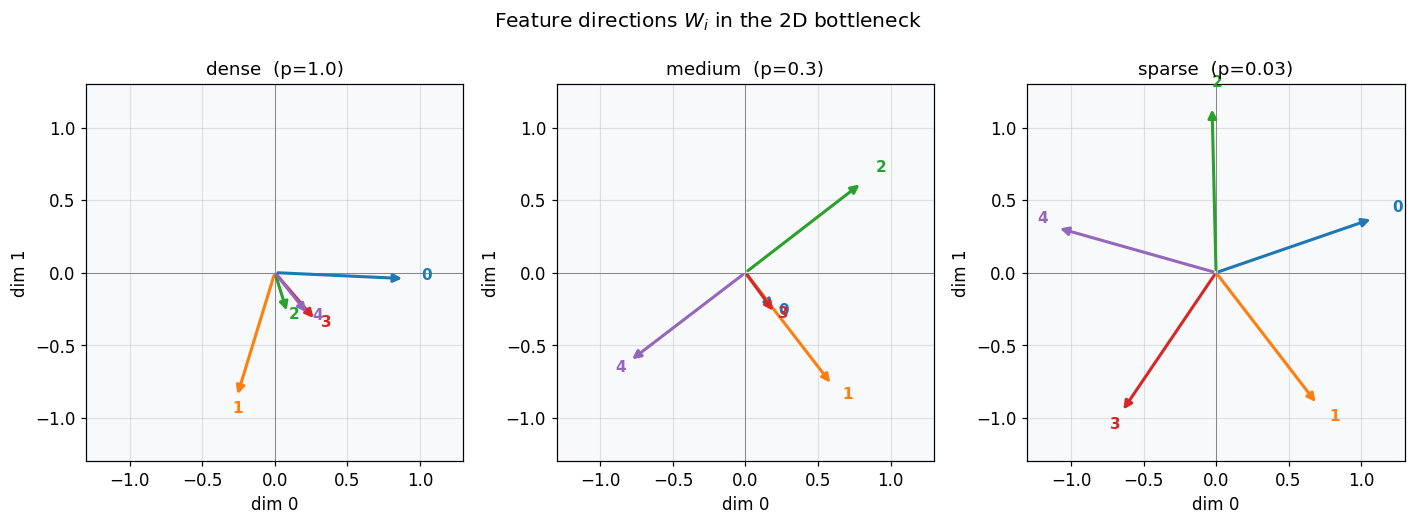

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
colors = plt.cm.tab10(np.arange(5))
titles = ['dense  (p=1.0)', 'medium  (p=0.3)', 'sparse  (p=0.03)']
for ax, W, title in zip(axes, Ws, titles):
    for i in range(5):
        ax.annotate('', xy=(W[0, i], W[1, i]), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='-|>', color=colors[i], lw=2))
        ax.text(1.12 * W[0, i], 1.12 * W[1, i], f'{i}', color=colors[i], fontsize=10, fontweight='bold')
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect('equal')
    ax.axhline(0, color='gray', lw=0.6); ax.axvline(0, color='gray', lw=0.6)
    ax.set_title(title); ax.set_xlabel('dim 0'); ax.set_ylabel('dim 1')
fig.suptitle('Feature directions $W_i$ in the 2D bottleneck', y=1.03)
plt.tight_layout(); plt.show()

### What you see

**Dense** ($p=1$): two features dominate (norm $\approx 0.9$) while the other three are strongly
suppressed (much shorter arrows). With features always co-active, interference is unaffordable, so the
model behaves like PCA — keep the few it can afford and shrink the rest.

**Sparse** ($p=0.03$): all five features appear with roughly equal norm, spread as a **regular
pentagon** — five directions evenly placed around the circle so no pair sits too close, minimising
interference. This is superposition: $5 > 2$ features packed into 2 dimensions because they rarely fire
together. The medium case sits in between. The geometry is not random — it is the uniform-polytope
structure the note describes.

## Experiment 3: The interference matrix $W^\top W$

**Question:** What does packing cost?

The matrix $W^\top W$ has $(i,j)$ entry $W_i^\top W_j$ — the overlap between feature directions. The
diagonal is each feature's squared norm; the **off-diagonal is interference**: feature $j$ firing
leaks $W_i^\top W_j$ into the readout of feature $i$.

In [5]:
W_dense = Ws[0]      # p = 1.0
W_sparse = Ws[2]     # p = 0.03
G_dense = W_dense.T @ W_dense
G_sparse = W_sparse.T @ W_sparse
print('sparse W^T W (off-diagonal = interference):')
print(np.round(G_sparse, 2))

sparse W^T W (off-diagonal = interference):
[[ 1.32  0.42  0.4  -1.07 -1.08]
 [ 0.42  1.32 -1.06  0.42 -1.05]
 [ 0.4  -1.06  1.32 -1.08  0.39]
 [-1.07  0.42 -1.08  1.35  0.42]
 [-1.08 -1.05  0.39  0.42  1.3 ]]


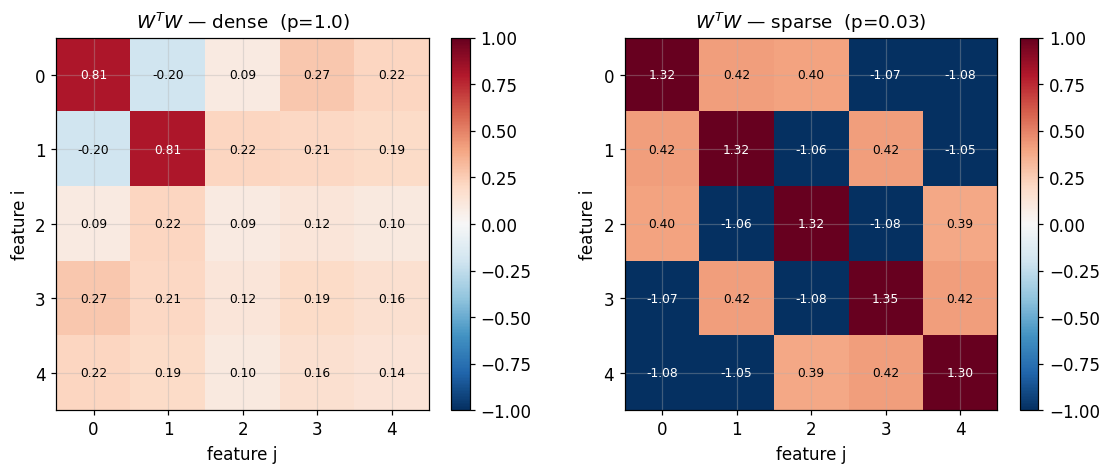

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.4))
for ax, G, title in [(axes[0], G_dense, 'dense  (p=1.0)'), (axes[1], G_sparse, 'sparse  (p=0.03)')]:
    im = ax.imshow(G, cmap='RdBu_r', vmin=-1, vmax=1)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{G[i, j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(G[i, j]) > 0.5 else 'black')
    ax.set_title(f'$W^T W$ — {title}'); ax.set_xlabel('feature j'); ax.set_ylabel('feature i')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

### What you see

**Dense**: $W^\top W$ is nearly a rank-2 projector — two features carry most of the diagonal norm and
the off-diagonals stay small. Little interference, but few features survive.

**Sparse**: the diagonal is uniformly non-zero (all five represented, $\lVert W_i\rVert^2 \approx 1.3$)
and the **off-diagonals are non-zero**. A regular pentagon has neighbours at $72°$ ($\cos\approx+0.31$)
and non-neighbours at $144°$ ($\cos\approx-0.81$); scaled by the squared norms this gives the $+0.42$
and $-1.07$ entries you see. That mixed-sign leakage is the interference the model accepts for capacity
— small enough that sparsity plus ReLU clipping keep reconstruction working. **Almost-orthogonal, not
orthogonal** — exactly the trade the note describes.

## Experiment 4: The phase transition

**Question:** How does the number of represented features change with sparsity?

We train an $n=20$, $m=5$ model across a sweep of activation probabilities and count how many features
end up with a meaningful direction ($\lVert W_i\rVert$ above a threshold). The note predicts a sharp
rise from $\approx m$ to $\approx n$ as features get sparser.

In [7]:
n, m = 20, 5
p_grid = np.array([1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.03, 0.02, 0.01])
n_repr = []
for p in p_grid:
    W, _ = train_toy(n=n, m=m, p=float(p), steps=6000, seed=2)
    norms = np.linalg.norm(W, axis=0)
    n_repr.append(int((norms > 0.5 * norms.max()).sum()))
for p, k in zip(p_grid, n_repr):
    print(f'p={p:<5}  features represented = {k:2d} / {n}')

p=1.0    features represented =  5 / 20
p=0.5    features represented =  9 / 20
p=0.3    features represented = 10 / 20
p=0.2    features represented = 15 / 20
p=0.1    features represented = 16 / 20
p=0.05   features represented = 20 / 20
p=0.03   features represented = 20 / 20
p=0.02   features represented = 20 / 20
p=0.01   features represented = 20 / 20


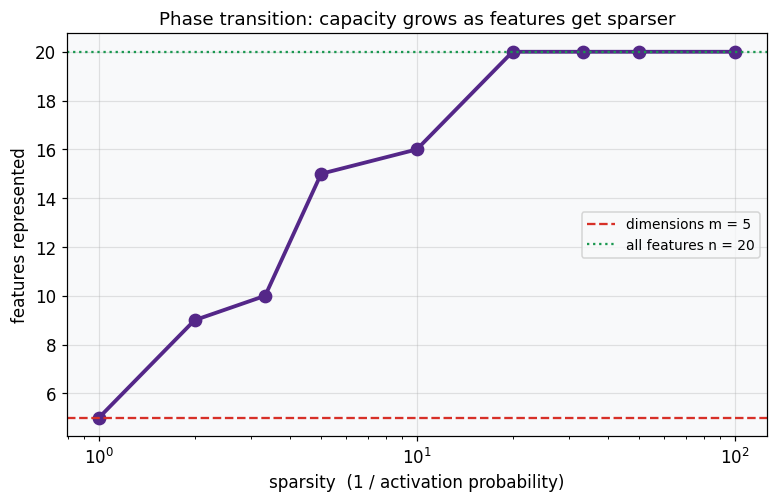

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.7))
sparsity = 1.0 / p_grid                      # higher = sparser
ax.plot(sparsity, n_repr, 'o-', lw=2.5, ms=8, color='#542788')
ax.axhline(m, color='#d73027', ls='--', label=f'dimensions m = {m}')
ax.axhline(n, color='#1a9850', ls=':', label=f'all features n = {n}')
ax.set_xscale('log')
ax.set_xlabel('sparsity  (1 / activation probability)')
ax.set_ylabel('features represented')
ax.set_title('Phase transition: capacity grows as features get sparser')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### What you see

At low sparsity (left) the model represents only about $m=5$ features — the dimension budget — behaving
like PCA. As sparsity increases (right), the count climbs well past $m$ toward $n=20$: the model packs
far more features than it has dimensions. This is the transition from the orthogonal (PCA-like) regime
to the **superposition** regime that Elhage et al. identified.

The single knob driving it is **sparsity**: rare co-activation is what makes interference affordable,
and affordability is what unlocks superposition.

## Experiment 5: Johnson–Lindenstrauss — room for near-orthogonal directions

**Question:** Why is there *space* to pack so many features?

Only $m$ vectors can be exactly orthogonal in $\mathbb{R}^m$, but **exponentially many** can be
*almost* orthogonal. We draw many random unit vectors and look at the distribution of pairwise
$|\cos|$ as the dimension $m$ grows.

In [9]:
def pairwise_abscos(m, n_vec=1500, seed=0):
    rng = np.random.RandomState(seed)
    V = rng.randn(n_vec, m); V /= np.linalg.norm(V, axis=1, keepdims=True)
    C = np.abs(V @ V.T)
    iu = np.triu_indices(n_vec, k=1)
    return C[iu]

ms = [2, 8, 32, 128]
cos_by_m = {m: pairwise_abscos(m) for m in ms}
p99 = {m: np.percentile(cos_by_m[m], 99) for m in ms}
for m in ms:
    print(f'm={m:4d}  median|cos|={np.median(cos_by_m[m]):.3f}  99th-pct|cos|={p99[m]:.3f}')

m=   2  median|cos|=0.707  99th-pct|cos|=1.000
m=   8  median|cos|=0.260  99th-pct|cos|=0.798
m=  32  median|cos|=0.122  99th-pct|cos|=0.442
m= 128  median|cos|=0.060  99th-pct|cos|=0.226


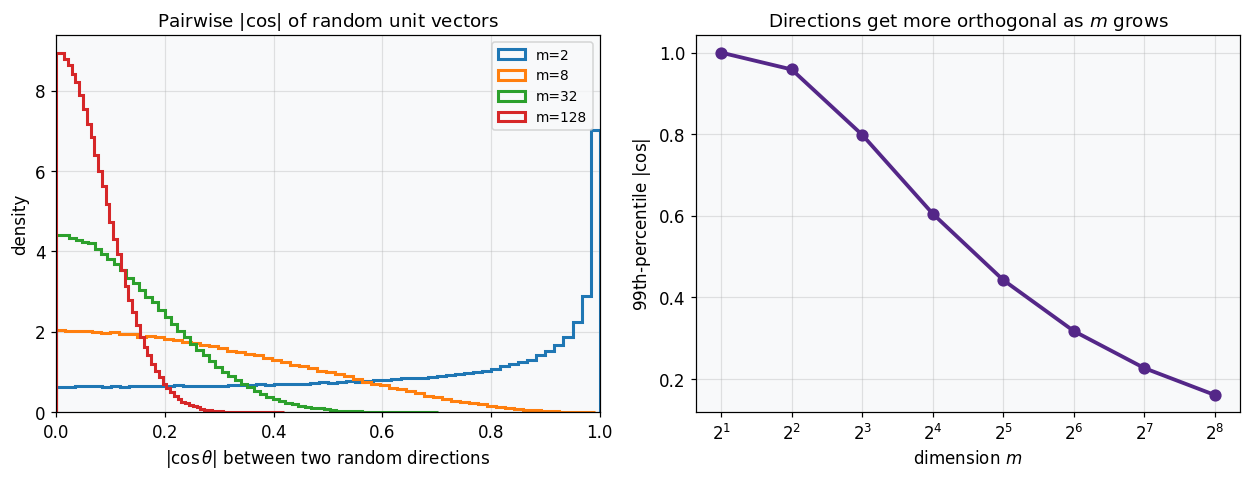

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
for m in ms:
    axes[0].hist(cos_by_m[m], bins=60, density=True, histtype='step', lw=2, label=f'm={m}')
axes[0].set_title('Pairwise $|\\cos|$ of random unit vectors')
axes[0].set_xlabel('$|\\cos\\theta|$ between two random directions'); axes[0].set_ylabel('density')
axes[0].legend(fontsize=9); axes[0].set_xlim(0, 1)
ms_curve = [2, 4, 8, 16, 32, 64, 128, 256]
p99_curve = [np.percentile(pairwise_abscos(m), 99) for m in ms_curve]
axes[1].plot(ms_curve, p99_curve, 'o-', lw=2.5, ms=7, color='#542788')
axes[1].set_xscale('log', base=2)
axes[1].set_title('Directions get more orthogonal as $m$ grows')
axes[1].set_xlabel('dimension $m$'); axes[1].set_ylabel('99th-percentile $|\\cos|$')
plt.tight_layout(); plt.show()

### What you see

Left: as $m$ grows, the distribution of $|\cos|$ between random directions collapses toward **zero** —
two random vectors in high dimensions are almost surely nearly orthogonal. Right: the 99th-percentile
$|\cos|$ shrinks steadily with $m$, so the *worst-case* interference between packed directions falls
as dimension rises.

This is the Johnson–Lindenstrauss intuition that makes superposition possible: high-dimensional
activation spaces have enough "almost-orthogonal room" to host far more feature directions than they
have axes — with interference small enough that sparsity and ReLU can clean it up.

## Experiment 6: Why PCA cannot recover superposed features

**Question:** Can the standard tool — PCA — un-mix superposition?

We train a sparse $n=8$, $m=4$ model, collect its activations $h=Wx$, and run PCA. PCA returns $m=4$
**orthogonal** components. We then check the alignment $|\cos|$ between each PCA component and each of
the 8 **true** feature directions.

In [11]:
n, m = 8, 4
Wsp, _ = train_toy(n=n, m=m, p=0.05, steps=8000, seed=3)
true_dirs = Wsp / np.linalg.norm(Wsp, axis=0, keepdims=True)   # (m, n) normalised columns

rng = np.random.RandomState(0)
Xs = (rng.random((20000, n)) < 0.05) * rng.random((20000, n))
H = Xs @ Wsp.T                                                  # activations (20000, m)
Hc = H - H.mean(0)
U, S, Vt = np.linalg.svd(Hc, full_matrices=False)
pca_dirs = Vt                                                   # (m, m) principal directions in R^m

align = np.abs(pca_dirs @ true_dirs)                            # (m PCA comps, n features)
print('rows = PCA components, cols = true features; |cos| alignment:')
print(np.round(align, 2))

rows = PCA components, cols = true features; |cos| alignment:
[[0.98 0.1  0.14 0.07 0.15 0.08 0.98 0.1 ]
 [0.06 0.97 0.24 0.   0.24 0.01 0.06 0.97]
 [0.17 0.19 0.87 0.42 0.86 0.42 0.17 0.21]
 [0.   0.11 0.41 0.9  0.42 0.9  0.01 0.11]]


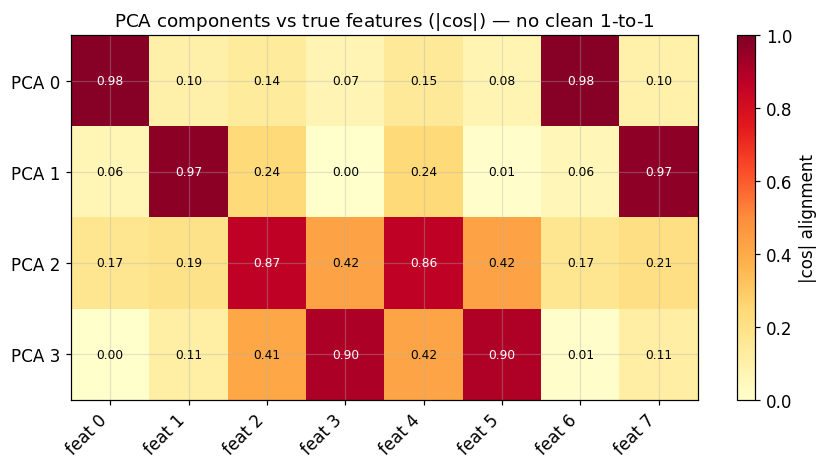

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.4))
im = ax.imshow(align, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
for i in range(align.shape[0]):
    for j in range(align.shape[1]):
        ax.text(j, i, f'{align[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if align[i, j] > 0.6 else 'black')
ax.set_xticks(range(n)); ax.set_xticklabels([f'feat {j}' for j in range(n)], rotation=45, ha='right')
ax.set_yticks(range(m)); ax.set_yticklabels([f'PCA {i}' for i in range(m)])
ax.set_title('PCA components vs true features ($|\\cos|$) — no clean 1-to-1')
fig.colorbar(im, ax=ax, label='|cos| alignment')
plt.tight_layout(); plt.show()

### What you see

There is **no clean permutation** in this heatmap. Each PCA component spreads its alignment across
*several* true features (a row with multiple warm cells), and several features are only weakly captured
by any component — because there are 8 non-orthogonal features but only 4 orthogonal PCA axes. PCA is
forced to return blended directions; it cannot isolate features that were never orthogonal and that
outnumber the dimensions.

This is the note's central practical consequence: **orthogonal decomposition (PCA) is the wrong tool
for a superposed latent.** Recovering the true features needs a method that assumes *sparsity* rather
than orthogonality — an overcomplete sparse dictionary, i.e. the **sparse autoencoder** that the next
note builds.

## Summary / Key Takeaways

- **Toy model** — $h=Wx$, $x'=\mathrm{ReLU}(W^\top h+b)$ on sparse features; the columns of $W$ are the
  feature directions we read superposition off of.
- **Exp 2** — Dense features → two dominant **orthogonal** axes (PCA-like), the rest suppressed; sparse
  features → a **regular pentagon**, five directions packed into two dimensions.
- **Exp 3** — $W^\top W$ shows the cost: non-zero **off-diagonal interference** (pentagon pairs at
  $72°/144°$, $\cos\approx+0.31/-0.81$), small enough for sparsity + ReLU to tolerate.
- **Exp 4** — A **phase transition**: features represented jump from $\approx m$ to $\approx n$ as
  sparsity rises — capacity is unlocked by rare co-activation.
- **Exp 5** — **Johnson–Lindenstrauss**: random directions get more orthogonal as $m$ grows, giving
  high-dim spaces room for far more near-orthogonal features than axes.
- **Exp 6** — **PCA cannot un-mix** superposition: orthogonal components blend non-orthogonal features;
  recovery needs a sparse, overcomplete dictionary (the next note's SAE).
